# Social Context and Physical Activity in the ExtraSensory Dataset

**Portfolio-clean version of a UC San Diego COGS 108 team project**

This notebook is a presentation-oriented version assembled from the original course deliverables.
It removes course-template instructions and redundant setup material while preserving the project's
analysis, code, outputs, methods, and conclusions. The original course notebooks should remain in the
repository as the historical record of the class submission.


## Team Project and Contribution Note

This was a **five-person team project** completed for COGS 108 at UC San Diego.

**Alex Li's contributions** included:
- project conceptualization and research-question development;
- background research and literature review;
- project coordination and original report writing;
- substantial hands-on work in **data preprocessing, exploratory data analysis, and visualization**;
- integrating the ExtraSensory behavioral data with **NOAA hourly weather data** and a **2015 non-workday / holiday calendar**;
- constructing and checking time/date keys, social-context variables, activity summaries, and contextual controls;
- examining time-of-day, environmental, weather, holiday, and user-level patterns before modeling.

The statistical modeling and final report were completed collaboratively. Credit to **Alexander Zhang,
Zongxi He, Jack Ding, and Logan Zeto** for their work on analysis, methodology, software, visualization,
data curation, editing, and interpretation.

For the original course-role summary and complete submission record, see the original notebooks in the repository.


## Research Question

Using the ExtraSensory minute-level in-the-wild dataset, is social context (alone vs with_friends vs with_co-workers) associated with the probability that a person is physically active in that same minute? We will define the outcome active_minute = 1 if any of the labels walking, running, or bicycling is present for that minute, and 0 otherwise. The main predictors will be the social labels (alone, with_friends, with_co-workers), and we will adjust for confounds using time-of-day, day-of-week, holiday indicator, local weather (temperature and precipitation), and environment context (for example at_home, at_work, outside). We will estimate associations using a mixed-effects logistic regression with a participant random intercept to account for repeated measures within individuals. Primary metrics will be odds ratios and marginal probability differences between social contexts with ninety-five percent confidence intervals, plus sensitivity analyses using alternative definitions of active_minute.



## Background and Prior Work

Physical activity is a core public-health behavior, but it is not only an individual choice—people’s activity levels are shaped by context, including who they are with. Social and behavioral research has repeatedly argued that social connection and support can influence whether people start and maintain physical activity, but the strength and direction of this relationship can vary depending on the source of the social influence (friends versus family) and the situation.1 This motivates our focus on separating with_friends and with_family rather than treating “being social” as one generic category.

Prior work also suggests that friends and family are not interchangeable in how they relate to physical activity. For example, Larsen et al. explicitly examined differences between family integration and friend integration and their association with physical activity, treating them as distinct social dimensions rather than one combined predictor.2 Similarly, Sarkar et al. compared different sources of social support (family, friends, coworkers) and analyzed how these relate to moderate-to-vigorous physical activity, reinforcing the idea that the “type” of social context matters for activity outcomes.3 These studies support our project design choice: we will estimate separate associations for with_friends and with_family relative to alone.

On the data science side, mobile and wearable sensing offers a way to study behavior in natural settings—but it is difficult because real-world behavior is unscripted and phone usage is unconstrained. The ExtraSensory project directly addresses this by providing a large-scale in-the-wild dataset with minute-level, multi-label context annotations (including social context labels) paired with smartphone/smartwatch sensor data, specifically designed to study detailed human context outside the lab.6 Because ExtraSensory includes both social labels and activity labels at the same time resolution, it enables our proposed statistical inference approach: estimating the association between being with friends or family and the likelihood of being active, while controlling for time structure and environment. Our work therefore connects behavior-science theory (social context matters) with a measurement approach suited to real life (minute-level in-the-wild context labels), and aims to quantify whether the association holds after adjustment for major confounds.

^ Golaszewski, N. M., et al. (2021). Group exercise membership is associated with forms of social support and exercise identity. (Background discussion on long history linking social support from family/friends to physical activity.) https://pmc.ncbi.nlm.nih.gov/articles/PMC9053316/
^ Larsen, B. A., et al. (2014). The Association Between Family and Friend Integration and Physical Activity: Results from the NHIS. https://pmc.ncbi.nlm.nih.gov/articles/PMC3796040/
^ Sarkar, S., et al. (2016). Social support for physical activity: Comparison of family, friends, and coworkers. https://pubmed.ncbi.nlm.nih.gov/28059824/
^ Vaizman, Y., Ellis, K., & Lanckriet, G. (2016). Recognizing Detailed Human Context In-the-Wild from Smartphones and Smartwatches. (ExtraSensory dataset motivation and design.) https://arxiv.org/abs/1609.06354


## Hypothesis


We hypothesize that minutes labeled with_friends will have a higher probability of active_minute = 1 than minutes labeled alone, even after controlling for time-of-day, day-of-week, environment, weather, and holidays.

The reasoning is that social time spent with friends is more likely to involve shared outings such as walking together to a destination, going to a restaurant/shop/attending an event, engaging in recreational activities, or meeting up on the way to work. So movement is often an inherent part of social interaction rather than a separate "exercise decision." In contrast, time spent alone involves more low-activity situations (such as studying/working at a desk, using electronic devices at home, or resting), which reduces essential activity minutes.

We also predict the association for with_family will be smaller and less consistent (closer to zero on average), because “with family” includes both active contexts (errands/outings) and sedentary contexts (meals and time at home).


## Data and Analysis Design

The project combines three sources:

1. **ExtraSensory** minute-level smartphone/smartwatch context labels and activity labels.
2. **NOAA Global Hourly** weather observations for 2015.
3. A **2015 non-workday / holiday calendar** used to distinguish workdays from weekends and holidays.

The ExtraSensory data contain repeated minute-level observations for 60 users. Activity is represented by
`active_minute`, defined from walking, running, or bicycling labels. The analysis focuses on social context
(`WITH_FRIENDS`, `WITH_CO-WORKERS`, and an "alone" reference category) while accounting for time of day,
environment, temperature, holiday status, and repeated observations within users.


### Data overview

- **Dataset #1**

  - **Dataset Name:** ExtraSensory Dataset — Features and Cleaned Context Labels (minute-level, in-the-wild)
  - **Link to the dataset:** ExtraSensory download page (features + labels zip; 215MB) from the ExtraSensory project website (Vaizman et al., 2017)
  - **Number of observations:** 377,346 minute-level rows in our combined raw load (60 users). After our analysis-focused processing (Option B: filling selected label NaNs with 0 and keeping only needed columns), the number of usable rows remains on the same order (still hundreds of thousands, exact count depends on final filters).
  - **Number of variables:** 279 columns in the raw combined dataset; we reduce to a modeling table of 21 columns (exact number depends on which controls are included, especially time-of-day bins).
  - **Description of the variables most relevant to this project:**

    - **Identifiers:** `user_id`, `timestamp`
    - **Primary predictor (social context):** `label:WITH_FRIENDS` (and optionally `label:WITH_CO-WORKERS`)
    - **Outcome construction:** `label:FIX_walking`, `label:FIX_running`, `label:BICYCLING` → combined into `active_minute` (1 if any are 1; else 0)
    - **Controls:** environment labels such as `label:LOC_home`, `label:LOC_main_workplace`, `label:OR_outside`, `label:OR_indoors`, and time-of-day indicator columns `discrete:time_of_day:*`
  - **Descriptions of any shortcomings this dataset has with respect to the project:**

    - **Key limitation:** the cleaned labels file we are using does not include explicit `alone` or `with_family` labels, so we can’t directly run the original three-category social comparison (alone vs friends vs family) without adding another data source.
    - **Missingness/labeling bias:** many labels are missing (NaN) because users did not label every minute; we observed systematic differences in missingness when `WITH_FRIENDS` is NaN vs observed, suggesting labeling is not random.
    - **Generalizability:** participants are volunteers using a phone app (and sometimes a watch), so the sample may not represent the general population.
    - **Repeated measures:** minute-level observations are not independent within a person, so analyses must account for within-subject correlation.

- **Dataset #2**

  - **Dataset Name**:U.S. Non-Working Days in 2015 (Public Holidays and Weekends)
  - **Link to the dataset**:Public holiday data sourced from Microsoft Azure Open Datasets – Public Holidays:https://learn.microsoft.com/en-us/azure/open-datasets/dataset-public-holidays
  - **Number of observations**:115 daily observations, corresponding to all non-working days in the United States in 2015. This includes all Saturdays and Sundays as well as all federally recognized public holidays.
  - **Number of variables**:2 variables

  - **Description of the variables most relevant to this project**:

    - **Date**: The calendar date in 2015 identified as a non-working day.

    - **holidayName**: The name of the public holiday if the date corresponds to a federally recognized holiday. For weekend dates that are not public holidays, this field is set to "Weekend".

  - **Description of any shortcomings this dataset has with respect to the project**:This dataset represents non-working days using a calendar-based definition rather than individual-level work schedules. While federal holidays and weekends are commonly associated with changes in daily routines, not all individuals observe the same holidays or take weekends off, particularly across different occupations or regions. Additionally, the dataset does not capture partial workdays, employer-specific observed holidays, or informal cultural observances. As a result, the dataset is best interpreted as indicating institutional non-working days rather than guaranteed days off for all individuals.

- **Dataset #3**

  - **Dataset Name**: NOAA Global Hourly Weather Dataset
  - **Link to the dataset**: https://www.ncei.noaa.gov/data/global-hourly/access/2015/72290023188.csv
  - **Number of observations**: 12,132
  - **Number of variables**: 89
  - **Description**:
    This dataset contains hourly weather observations from station 72290023188 in 2015. Each row represents one hour of recorded weather data. The key variable for this project is air temperature (TMP), which is recorded in tenths of degrees Celsius and was converted to degrees Celsius during cleaning. Missing values were originally coded as 9999 and were converted to NA.
  
    One limitation is that the data come from a single weather station, which may not perfectly reflect local conditions experienced by participants. In addition, the data are hourly and must be aligned with minute-level activity data when merging datasets.


## Exploratory Data Analysis

The following cells preserve the main EDA from the course project while removing course-template instructions.
The analysis checks data quality and baseline rates, evaluates potential confounders, and examines heterogeneity
before regression modeling.


In [18]:
# Set up #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ex = pd.read_csv("data/02-processed/extrasensory_processed_model.csv")
temp = pd.read_csv("data/02-processed/noaa_hourly_cleaned.csv", low_memory=False)
holi = pd.read_csv("data/02-processed/non_workdays_2015.csv")

print(ex.shape, temp.shape, holi.shape)

(377346, 17) (11752, 89) (114, 2)


In [19]:
# Sanity check #
print("Duplicate (user_id, timestamp):", ex.duplicated(["user_id","timestamp"]).sum())
print("Users:", ex["user_id"].nunique())
display(ex.head())

# check the key variables
key_cols = ["active_minute", "label:WITH_FRIENDS", "label:WITH_CO-WORKERS"]
print(ex[key_cols].describe())

Duplicate (user_id, timestamp): 0
Users: 60


,user_id,timestamp,active_minute,label:WITH_FRIENDS,label:WITH_CO-WORKERS,label:LOC_home,label:LOC_main_workplace,label:OR_outside,label:OR_indoors,discrete:time_of_day:between0and6,discrete:time_of_day:between3and9,discrete:time_of_day:between6and12,discrete:time_of_day:between9and15,discrete:time_of_day:between12and18,discrete:time_of_day:between15and21,discrete:time_of_day:between18and24,discrete:time_of_day:between21and3
0,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079161,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079221,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079281,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079341,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079431,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


       active_minute  label:WITH_FRIENDS  label:WITH_CO-WORKERS
count  377346.000000       377346.000000          377346.000000
mean        0.074854            0.065555               0.016494
std         0.263157            0.247503               0.127366
min         0.000000            0.000000               0.000000
25%         0.000000            0.000000               0.000000
50%         0.000000            0.000000               0.000000
75%         0.000000            0.000000               0.000000
max         1.000000            1.000000               1.000000


The sanity check results show that there are no duplicate observations based on the combination of user_id and timestamp, indicating that each record represents a unique observation in time for each user. The dataset contains 60 unique users and a total of 377,346 observations, suggesting a relatively large behavioral dataset.

The summary statistics of key variables provide additional insight into the data distribution. The mean value of active_minute is approximately 0.075, which indicates that users are active in about 7.5% of the recorded time intervals. Social interaction labels such as WITH_FRIENDS (mean ≈ 0.066) and WITH_CO_WORKERS (mean ≈ 0.016) appear relatively infrequent, suggesting that most recorded moments occur outside these social contexts. These statistics help us understand the baseline behavioral patterns before incorporating additional variables such as weather or holidays.

In [20]:
# Base rates (descriptive)
active_rate = ex["active_minute"].mean()
friends_rate = ex["label:WITH_FRIENDS"].mean()
cowork_rate = ex["label:WITH_CO-WORKERS"].mean()

print("active_minute rate:", round(active_rate, 4))
print("WITH_FRIENDS rate:", round(friends_rate, 4))
print("WITH_CO-WORKERS rate:", round(cowork_rate, 4))

# Conditional rates (descriptive)
ct = ex.groupby("label:WITH_FRIENDS")["active_minute"].mean()
print("\nP(active|WITH_FRIENDS):")
print(ct)

# Simple difference in proportions
diff = ct.loc[1] - ct.loc[0] if 1 in ct.index and 0 in ct.index else np.nan
print("\nDifference in active rate (friends - not friends):", diff)

active_minute rate: 0.0749
WITH_FRIENDS rate: 0.0656
WITH_CO-WORKERS rate: 0.0165

P(active|WITH_FRIENDS):
label:WITH_FRIENDS
0.0    0.068421
1.0    0.166552
Name: active_minute, dtype: float64

Difference in active rate (friends - not friends): 0.098130732453527


The results show that the overall probability of being active is about 7.5%. Being with friends occurs in approximately 6.6% of observations, while being with co-workers occurs much less frequently (about 1.7%). When examining conditional activity rates, we observe a clear difference: the probability of being active when users are not with friends is about 6.8%, whereas it increases to about 16.7% when users are with friends. This difference of roughly 9.8 percentage points suggests that social interaction with friends is strongly associated with higher activity levels. One possible explanation is that activities with friends often involve movement or social events that require physical activity.

**Time-of-day confounding**

tod_bin
between0and6      0.006321
between12and18    0.102033
between15and21    0.098845
between18and24    0.044344
between3and9      0.085674
between6and12     0.118559
between9and15     0.109452
Name: active_minute, dtype: float64


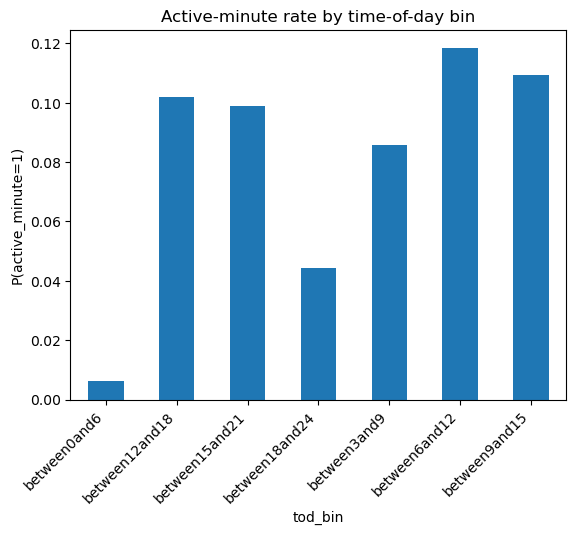

In [21]:
tod_cols = [c for c in ex.columns if c.startswith("discrete:time_of_day:")]
ex["tod_bin"] = ex[tod_cols].idxmax(axis=1).str.replace("discrete:time_of_day:", "", regex=False)

# Active rate by time bin
tod_active = ex.groupby("tod_bin")["active_minute"].mean().sort_index()
print(tod_active)

# Plot active rate by time bin
plt.figure()
tod_active.plot(kind="bar")
plt.title("Active-minute rate by time-of-day bin")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.show()

This show a clear time-of-day pattern in physical activity. Activity rates are extremely low during the early morning hours (between midnight and 6 a.m.), which is expected since most people are likely sleeping. Activity levels increase significantly during the morning and daytime periods, peaking around the morning-to-afternoon hours (between 6 a.m. and 3 p.m.). Activity rates begin to decline again in the evening and are relatively lower during the late-night period. These findings suggest that time of day strongly influences activity behavior. As a result, time-of-day may act as a confounding variable when analyzing other factors such as weather or social context.

label:WITH_FRIENDS       0.0       1.0
tod_bin                               
between0and6        0.004717  0.058728
between12and18      0.095253  0.185693
between15and21      0.091335  0.158132
between18and24      0.037260  0.120638
between3and9        0.073870  0.399717
between6and12       0.110300  0.257015
between9and15       0.107726  0.130107


<Figure size 640x480 with 0 Axes>

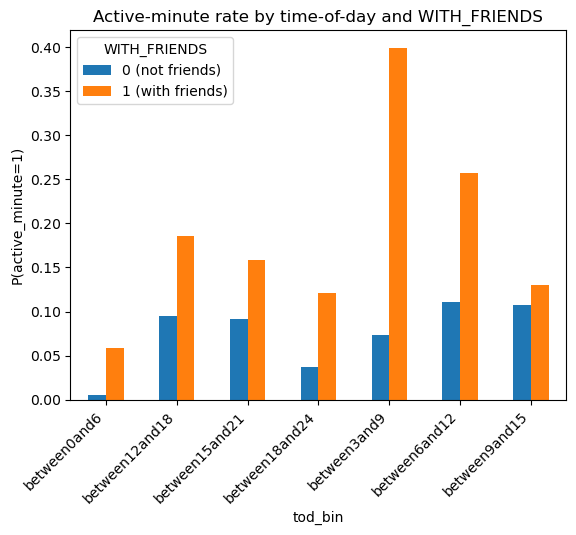

In [22]:
# Friends vs not friends within time bins
pivot = ex.pivot_table(
    index="tod_bin",
    columns="label:WITH_FRIENDS",
    values="active_minute",
    aggfunc="mean"
).sort_index()

print(pivot)

plt.figure()
pivot.plot(kind="bar")
plt.title("Active-minute rate by time-of-day and WITH_FRIENDS")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="WITH_FRIENDS", labels=["0 (not friends)", "1 (with friends)"])
plt.show()

The results show that activity levels are consistently higher when users are with friends across all time-of-day bins. However, the magnitude of this difference varies depending on the time period. The largest gap appears during the early morning and morning hours, where activity rates with friends are substantially higher than when users are alone. This suggests that social interaction may strongly encourage physical activity, particularly during daytime periods when people are more likely to engage in social or recreational activities. Overall, both time of day and social context appear to play important roles in shaping activity behavior.

**Environmental Confounding (home / workplace / outside)**

label:OR_indoors            0.489450
label:LOC_home              0.405177
label:LOC_main_workplace    0.089955
label:OR_outside            0.032103
dtype: float64

Active rate by WITH_FRIENDS and label:OR_outside
label:WITH_FRIENDS  label:OR_outside
0.0                 0.0                 0.053907
                    1.0                 0.607858
1.0                 0.0                 0.100448
                    1.0                 0.669217
Name: active_minute, dtype: float64

Active rate by WITH_FRIENDS and label:OR_indoors
label:WITH_FRIENDS  label:OR_indoors
0.0                 0.0                 0.115695
                    1.0                 0.020138
1.0                 0.0                 0.252571
                    1.0                 0.044976
Name: active_minute, dtype: float64

Active rate by WITH_FRIENDS and label:LOC_home
label:WITH_FRIENDS  label:LOC_home
0.0                 0.0               0.104316
                    1.0               0.019145
1.0                 0.

<Figure size 640x480 with 0 Axes>

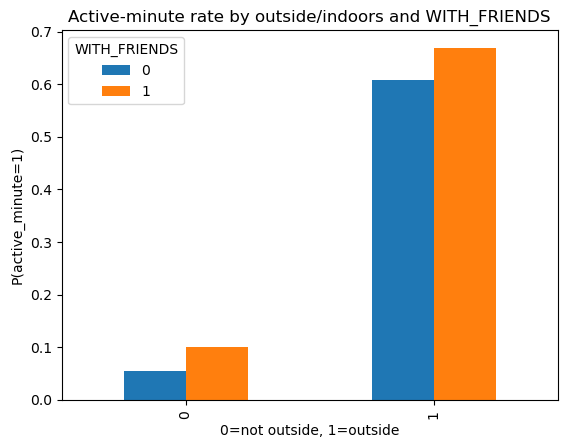

In [23]:
env_cols = ["label:LOC_home","label:LOC_main_workplace","label:OR_outside","label:OR_indoors"]
print(ex[env_cols].mean().sort_values(ascending=False))

# Active by friends within outside vs indoors
for env in ["label:OR_outside", "label:OR_indoors", "label:LOC_home", "label:LOC_main_workplace"]:
    tab = ex.groupby(["label:WITH_FRIENDS", env])["active_minute"].mean()
    print("\nActive rate by WITH_FRIENDS and", env)
    print(tab)

# Plot
df_plot = ex.copy()
df_plot["outside_flag"] = df_plot["label:OR_outside"].astype(int)

plot_tab = df_plot.pivot_table(
    index="outside_flag",
    columns="label:WITH_FRIENDS",
    values="active_minute",
    aggfunc="mean"
)

plt.figure()
plot_tab.plot(kind="bar")
plt.title("Active-minute rate by outside/indoors and WITH_FRIENDS")
plt.xlabel("0=not outside, 1=outside")
plt.ylabel("P(active_minute=1)")
plt.legend(title="WITH_FRIENDS", labels=["0", "1"])
plt.show()

The results reveal a strong relationship between environment and activity behavior. Activity rates are substantially higher when users are outside compared to when they are indoors or not outside. This is expected, since many outdoor contexts involve movement such as walking or recreational activities.

Additionally, activity rates are consistently higher when users are with friends than when they are not with friends. The highest activity levels occur when users are both outside and with friends. This suggests that environmental context and social interaction may jointly influence activity behavior. Therefore, location (indoors vs. outdoors) may also act as an important confounding factor when studying the relationship between social context and physical activity.

,n_minutes,active_rate,friends_rate,active_not_friends,active_with_friends,within_user_diff
count,60.000000,60.000000,60.000000,60.000000,32.000000,32.000000
mean,6289.100000,0.076705,0.065501,0.072033,0.189705,0.117308
std,2482.909684,0.044922,0.107134,0.044849,0.259998,0.266853
min,1600.000000,0.004812,0.000000,0.001035,0.000000,-0.173096
25%,3947.750000,0.041576,0.000000,0.040199,0.013122,-0.038661
50%,6312.500000,0.069072,0.003814,0.059887,0.105670,0.022363
75%,8177.750000,0.104574,0.083166,0.099246,0.218773,0.165769
max,11996.000000,0.203696,0.416162,0.203018,1.000000,0.998965


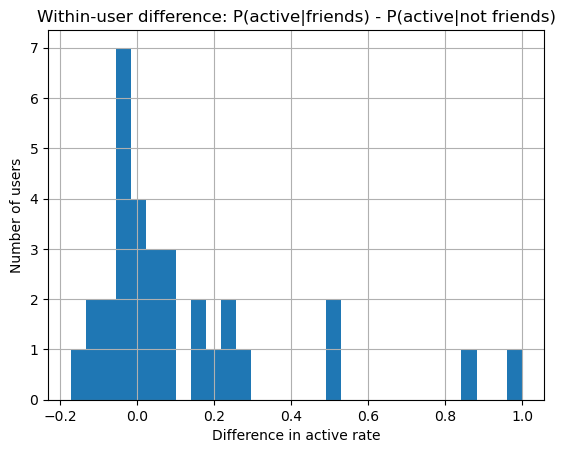

In [24]:
# User-level variability (justifies mixed effects)
user_summary = ex.groupby("user_id").agg(
    n_minutes=("active_minute","size"),
    active_rate=("active_minute","mean"),
    friends_rate=("label:WITH_FRIENDS","mean")
)

# Within-user active rates for friends vs not friends
tmp = ex.groupby(["user_id","label:WITH_FRIENDS"])["active_minute"].mean().unstack()
tmp.columns = ["active_not_friends","active_with_friends"]
user_summary = user_summary.join(tmp)

user_summary["within_user_diff"] = user_summary["active_with_friends"] - user_summary["active_not_friends"]

display(user_summary.describe())

plt.figure()
user_summary["within_user_diff"].dropna().hist(bins=30)
plt.title("Within-user difference: P(active|friends) - P(active|not friends)")
plt.xlabel("Difference in active rate")
plt.ylabel("Number of users")
plt.show()

The user-level analysis reveals substantial variability across individuals. On average, the probability of being active when users are with friends (≈0.19) is notably higher than when they are not with friends (≈0.07). The mean within-user difference in activity rates is approximately 0.12, suggesting that social interaction is generally associated with increased activity.

However, the histogram shows that this effect is not uniform across users. Some individuals exhibit little difference, while others show a very large increase in activity when they are with friends. A few users even show negative differences, indicating that they may be less active when with friends. This heterogeneity suggests that user-specific factors play an important role in activity behavior, supporting the use of models that account for individual-level variation

#### NOAA Weather EDA (secondary dataset)

DATE         0.0
TMP_value    0.0
dtype: float64
count    11752.000000
mean        19.252519
std          4.231847
min          5.000000
25%         16.700000
50%         18.900000
75%         22.200000
max         35.600000
Name: TMP_value, dtype: float64


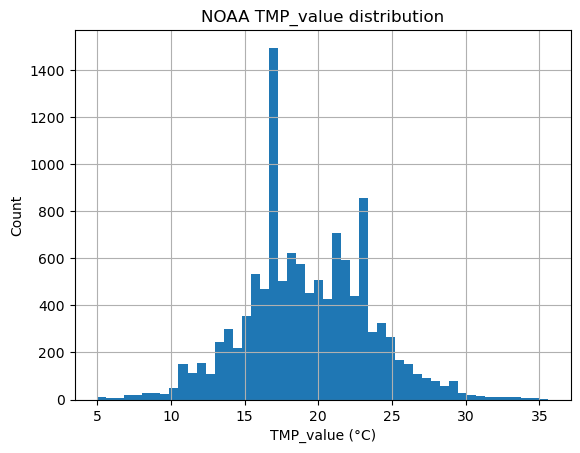

In [25]:
# Keep only what we need for EDA
noaa = temp[["DATE", "TMP_value", "STATION"]].copy()

# Parse datetime
noaa["DATE"] = pd.to_datetime(noaa["DATE"], errors="coerce")

# TMP_value should be numeric
noaa["TMP_value"] = pd.to_numeric(noaa["TMP_value"], errors="coerce")

print(noaa[["DATE","TMP_value"]].isna().mean())
print(noaa["TMP_value"].describe())

plt.figure()
noaa["TMP_value"].dropna().hist(bins=50)
plt.title("NOAA TMP_value distribution")
plt.xlabel("TMP_value (°C)")
plt.ylabel("Count")
plt.show()

The summary statistics indicate that the dataset contains 11,752 temperature observations. The average temperature is approximately 19.3°C, with values ranging from about 5°C to 35.6°C. This range is consistent with typical annual temperature variations in many regions. The histogram shows that most temperature values are concentrated between roughly 15°C and 25°C, suggesting that moderate temperatures occur most frequently in the dataset. Overall, the distribution appears reasonably continuous and does not exhibit obvious extreme outliers, indicating that the temperature data is suitable for further analysis and integration with the activity dataset.

#### Holiday / non-workdays EDA (third dataset)

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [26]:
holi["date"] = pd.to_datetime(holi["date"], errors="coerce")
print(holi.shape)
print("Unique holiday dates:", holi["date"].nunique())
display(holi.head())

(114, 2)
Unique holiday dates: 114


,date,holidayName
0,2015-01-01,New Year's Day
1,2015-01-03,Weekend
2,2015-01-04,Weekend
3,2015-01-10,Weekend
4,2015-01-11,Weekend


The preview of the dataset shows that it includes both official holidays, such as New Year's Day, and regular weekends. In total, the dataset contains 114 unique non-working days. These dates will later be used to create indicators for holidays or weekends when merging the dataset with the activity records. This allows us to investigate whether physical activity behavior differs between working days and non-working days

#### Merge EDA

ExtraSensory processed file has only timestamp and no lat/long. That means you can only merge weather if you already decided on a single station/region and align by time. If your NOAA data is for one station (or a known area), this is fine.

Holiday match rate: 0.25733676784701576
Rows before merge: 377346
Rows after holiday merge: 377346
holiday_bin
0    0.072848
1    0.080645
Name: active_minute, dtype: float64


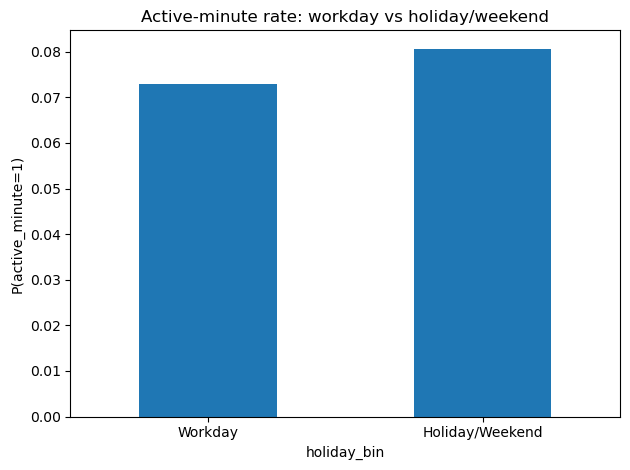

In [27]:
ex2 = ex.copy()
ex2["datetime"] = pd.to_datetime(ex2["timestamp"], unit="s", errors="coerce")

ex2["date"] = ex2["datetime"].dt.normalize()
holi2 = holi.copy()
holi2["date"] = pd.to_datetime(holi2["date"]).dt.normalize()

ex2 = ex2.merge(holi2[["date","holidayName"]], on="date", how="left")
ex2["is_holiday"] = ex2["holidayName"].notna().astype(int)

print("Holiday match rate:", ex2["is_holiday"].mean())

# Check for errors, omissions, or duplicates after merging.
print("Rows before merge:", len(ex))
print("Rows after holiday merge:", len(ex2))

# holiday_bin: 0=Workday, 1=Holiday/Weekend
if "holiday_bin" not in ex2.columns:
    ex2["holiday_bin"] = ex2["is_holiday"].fillna(0).astype(int)

holiday_active = ex2.groupby("holiday_bin")["active_minute"].mean()
print(holiday_active)

plt.figure()
holiday_active.plot(kind="bar")
plt.title("Active-minute rate: workday vs holiday/weekend")
plt.ylabel("P(active_minute=1)")
plt.xticks([0,1], ["Workday", "Holiday/Weekend"], rotation=0)
plt.tight_layout()
plt.show()

The figure compares activity rates between workdays and holidays/weekends. After merging the activity data with the holiday dataset, about 25.7% of observations correspond to holidays or weekends. The average active-minute rate is 0.073 on workdays and 0.081 on holidays or weekends, indicating slightly higher activity levels during non-working days. This pattern suggests that individuals may have more opportunities for physical activity when they have more free time outside of work.


[Weather merge QA]
Rows before/after: 377346 -> 377346
Weather match rate (TMP_value notna): 0.9394057443301373
Weather missing rate: 0.06059425566986267


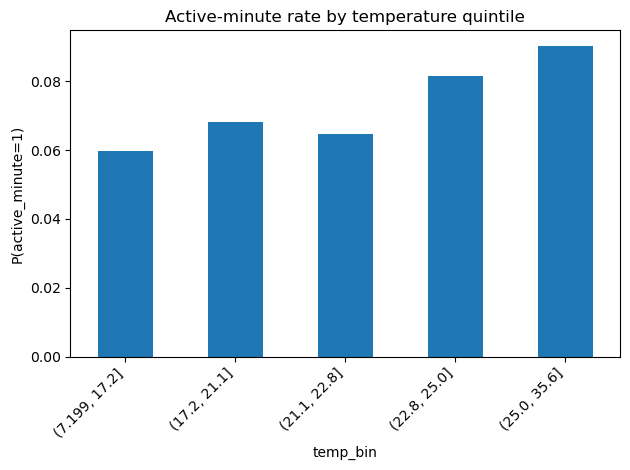

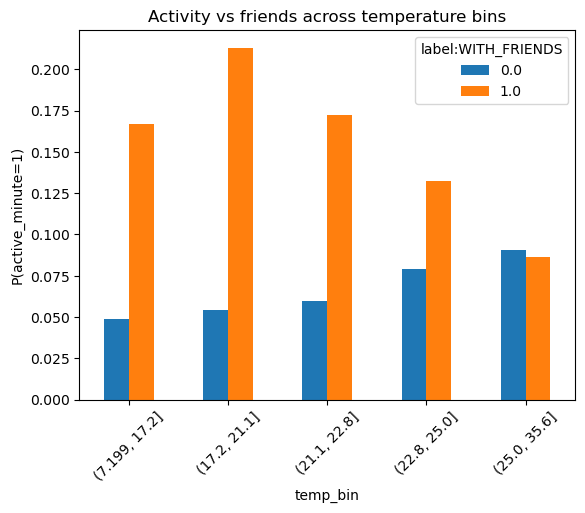

In [28]:
# Ensure keys exist (idempotent) ---
if "datetime" not in ex2.columns:
    ex2["datetime"] = pd.to_datetime(ex2["timestamp"], unit="s", errors="coerce")
if "hour" not in ex2.columns:
    ex2["hour"] = ex2["datetime"].dt.floor("h")

# Round ex2 to hour, and noaa to hour
noaa2 = noaa.dropna(subset=["DATE"]).copy()
noaa2["hour"] = noaa2["DATE"].dt.floor("h")

# Aggregate hourly temperature
noaa_hourly = noaa2.groupby("hour", as_index=False)["TMP_value"].mean()

# IMPORTANT: make this cell idempotent (safe to rerun)
for col in ["TMP_value", "TMP_value_x", "TMP_value_y"]:
    if col in ex2.columns:
        ex2 = ex2.drop(columns=col)

rows_before = len(ex2)

ex2 = ex2.merge(noaa_hourly, on="hour", how="left")

print("\n[Weather merge QA]")
print("Rows before/after:", rows_before, "->", len(ex2))
print("Weather match rate (TMP_value notna):", ex2["TMP_value"].notna().mean())
print("Weather missing rate:", ex2["TMP_value"].isna().mean())

#EDA: Activity vs Temperature bins
ex2["temp_bin"] = pd.qcut(ex2["TMP_value"], 5, duplicates="drop")
temp_active = ex2.groupby("temp_bin")["active_minute"].mean().sort_index()

plt.figure()
temp_active.plot(kind="bar")
plt.title("Active-minute rate by temperature quintile")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

temp_friend_active = ex2.groupby(
    ["temp_bin","label:WITH_FRIENDS"]
)["active_minute"].mean().unstack()

temp_friend_active.plot(kind="bar")
plt.title("Activity vs friends across temperature bins")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45)
plt.show()

We further examine how social context interacts with environmental conditions by comparing activity rates across temperature bins and whether users are with friends. The results show that activity levels are consistently higher when users are with friends (label:WITH_FRIENDS = 1) than when they are not. The difference is especially large in cooler and moderate temperature ranges, where the probability of an active minute is substantially higher when users are with friends. As temperature increases, activity levels rise overall, but the gap between being with friends and not being with friends becomes smaller in the warmest temperature group. This suggests that both temperature and social interaction influence physical activity, with social context playing a particularly strong role in encouraging activity.

In [35]:
ex2.head()

,user_id,timestamp,active_minute,label:WITH_FRIENDS,label:WITH_CO-WORKERS,label:LOC_home,label:LOC_main_workplace,label:OR_outside,label:OR_indoors,discrete:time_of_day:between0and6,discrete:time_of_day:between3and9,discrete:time_of_day:between6and12,discrete:time_of_day:between9and15,discrete:time_of_day:between12and18,discrete:time_of_day:between15and21,discrete:time_of_day:between18and24,discrete:time_of_day:between21and3,tod_bin,datetime,date,holidayName,is_holiday,holiday_bin,hour,TMP_value,temp_bin
0,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079161,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,between9and15,2015-10-05 21:06:01,2015-10-05,NaN,0,0,2015-10-05 21:00:00,19.8,"(17.2, 21.1]"
1,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079221,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,between9and15,2015-10-05 21:07:01,2015-10-05,NaN,0,0,2015-10-05 21:00:00,19.8,"(17.2, 21.1]"
2,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079281,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,between9and15,2015-10-05 21:08:01,2015-10-05,NaN,0,0,2015-10-05 21:00:00,19.8,"(17.2, 21.1]"
3,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079341,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,between9and15,2015-10-05 21:09:01,2015-10-05,NaN,0,0,2015-10-05 21:00:00,19.8,"(17.2, 21.1]"
4,00EABED2-271D-49D8-B599-1D4A09240601.features_labels,1444079431,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,between9and15,2015-10-05 21:10:31,2015-10-05,NaN,0,0,2015-10-05 21:00:00,19.8,"(17.2, 21.1]"


## Statistical Modeling

### Baseline Logistic Regression

A baseline logistic regression estimates the association between social context and minute-level physical activity
while controlling for temperature, holiday status, and environment. Because minute-level observations are repeated
within participants, this model is treated as a baseline rather than the preferred inferential specification.


In [4]:
df4 = ex2.copy()
df4["with_friends"] = (df4["label:WITH_FRIENDS"] == 1).astype(int)
df4["with_coworkers"] = (df4["label:WITH_CO-WORKERS"] == 1).astype(int)
df4["outside"] = (df4["label:OR_outside"] == 1).astype(int)
df4["home"] = (df4["label:LOC_home"] == 1).astype(int)
df4["workplace"] = (df4["label:LOC_main_workplace"] == 1).astype(int)
df4 = df4.dropna(subset=[
    "active_minute",
    "with_friends",
    "with_coworkers",
    "TMP_value",
    "is_holiday"
])
import statsmodels.api as sm

X = df4[[
    "with_friends",
    "with_coworkers",
    "TMP_value",
    "is_holiday",
    "outside",
    "home",
    "workplace"
]]

y = df4["active_minute"]

X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.217283
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          active_minute   No. Observations:               354481
Model:                          Logit   Df Residuals:                   354473
Method:                           MLE   Df Model:                            7
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.1649
Time:                        05:03:24   Log-Likelihood:                -77023.
converged:                       True   LL-Null:                       -92234.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.8985      0.035    -82.034      0.000      -2.968      -2.829
with_friends     

As a baseline specification, we first estimate a logistic regression model where the dependent variable is whether a participant is physically active in a given minute (active_minute). The main explanatory variables indicate whether the participant is with friends or with coworkers, and we control for contextual factors including temperature, holiday status, and location. The results from this baseline model suggest that social context is positively associated with physical activity: participants are more likely to be active when they are with friends or coworkers compared to when they are alone. However, this specification assumes that all observations are independent, while the dataset contains repeated minute-level observations for the same individuals. Ignoring this within-participant correlation may lead to underestimated standard errors and overly precise inference, which motivates the improved specification presented in the second model.

### Clustered Logistic Regression with Generalized Estimating Equations (GEE)

The improved specification uses **GEE with a binomial family**, clustering observations by `user_id` to account for
within-person correlation. Social context is modeled categorically with **alone** as the reference group, and the
model additionally controls for time of day, holiday status, temperature bins, and environmental context.


In [5]:
#Improved model selection, variable design, and control.
#Preparation
import numpy as np

#Drop observations that being with friends and being together at the same time. (only 0.2%, so not gonna affect)
ex2 = ex2[
    ~(
        (ex2["label:WITH_FRIENDS"] == 1) &
        (ex2["label:WITH_CO-WORKERS"] == 1)
    )
]

#Create needed variable
ex2["alone"] = (
    (ex2["label:WITH_FRIENDS"] == 0) &
    (ex2["label:WITH_CO-WORKERS"] == 0)
).astype(int)

ex2["social_context"] = np.select(
    [
        ex2["alone"] == 1,
        ex2["label:WITH_FRIENDS"] == 1,
        ex2["label:WITH_CO-WORKERS"] == 1
    ],
    [
        "alone",
        "friends",
        "coworkers"
    ],
    default=np.nan
)

ex2["social_context"] = ex2["social_context"].astype("category")
ex2["social_context"] = ex2["social_context"].cat.reorder_categories(
    ["alone","friends","coworkers"]
)

ex2["tod_bin"] = ex2["tod_bin"].astype("category")
ex2["temp_bin"] = ex2["temp_bin"].astype("category")

model_df = ex2[
    [
        "active_minute",
        "social_context",
        "tod_bin",
        "holiday_bin",
        "temp_bin",
        "label:LOC_home",
        "label:LOC_main_workplace",
        "label:OR_outside",
        "label:OR_indoors",
        "user_id"
    ]
].copy()

#This column contains some NaN values, approximately 6%, which can be droped.
model_df = model_df.dropna(subset=["temp_bin"])

#GEE clustered logistic regression
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.gee(
    "active_minute ~ C(social_context) + C(tod_bin) + holiday_bin + C(temp_bin) + \
     Q('label:LOC_home') + Q('label:LOC_main_workplace') + Q('label:OR_outside') + Q('label:OR_indoors')",
    groups="user_id",
    data=model_df,
    family=sm.families.Binomial()
)

result = model.fit()

print(result.summary())

                               GEE Regression Results                              
Dep. Variable:               active_minute   No. Observations:               353670
Model:                                 GEE   No. clusters:                       56
Method:                        Generalized   Min. cluster size:                1600
                      Estimating Equations   Max. cluster size:               11996
Family:                           Binomial   Mean cluster size:              6315.5
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Sat, 14 Mar 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         05:03:45
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -4.2247     

**Improved Model**

To address this issue, we estimated a clustered logistic regression using Generalized Estimating Equations (GEE), grouping observations by participant ID. This approach accounts for within-person correlation and produces more reliable statistical inference.

The improved model also includes additional control variables such as time-of-day categories and temperature bins, which better capture behavioral patterns and environmental conditions.

After applying these improvements, the coefficients for social context become statistically insignificant. This indicates that the apparent relationship between social interaction and physical activity observed in the baseline model is largely explained by contextual factors.

**Interpretation of Variables**
**Social Context**

Using being alone as the baseline category, the coefficients for both being with friends (β = 0.473, p = 0.159) and being with coworkers (β = 0.901, p = 0.234) are positive but not statistically significant. This suggests that although activity appears higher when individuals are with others, the differences are not statistically reliable after controlling for other contextual factors.

This result differs from the EDA findings, where the raw activity rates were noticeably higher when participants were with friends or coworkers compared to being alone. The regression results indicate that this difference is largely explained by other variables, such as location and time of day, rather than social context itself.

**Time of Day**
Time-of-day variables show strong and statistically significant effects. Most daytime periods have large positive coefficients, indicating that participants are significantly more likely to be physically active during daytime hours compared to the baseline period. This result is consistent with typical daily activity patterns, where most physical movement occurs during the day.

**Temperature**

Temperature bins are not statistically significant predictors of activity. This suggests that within the observed temperature range in the dataset, weather conditions do not have a strong effect on minute-level physical activity.

**Holiday**

The holiday indicator is also not statistically significant, indicating that participants do not exhibit meaningful differences in activity levels between holidays and non-holidays in this dataset.

**Environmental Context**

Environmental variables have the strongest effects in the model.

Being outside has a large positive and statistically significant coefficient (β = 2.431, p < 0.001), indicating a much higher likelihood of physical activity when participants are outdoors. In contrast, being at home (β = −0.494, p = 0.009) or at the main workplace (β = −1.161, p < 0.001) is associated with lower activity levels. Being indoors also significantly reduces the probability of physical activity.

**Comparison with EDA**

The effects of most variables are broadly consistent with the patterns observed in our exploratory data analysis (EDA), although the magnitude of these effects differs in the regression model. In the EDA, we identified clear associations between several contextual variables and the probability of physical activity, including time of day, environmental context, and social context. After controlling for multiple variables in the regression model, the overall directional patterns remain largely similar. For example, outdoor environments remain strongly associated with higher activity levels, while indoor settings, home environments, and workplaces are associated with lower probabilities of physical activity. This suggests that the general trends observed in the EDA are largely confirmed by the more rigorous statistical model.

However, the regression results show that after controlling for other variables such as time of day and environmental context, the holiday indicator is no longer statistically significant. This suggests that the higher activity levels observed during holidays in the exploratory analysis are unlikely to be directly caused by the holiday status itself.

Instead, holidays are often associated with changes in daily behavior patterns. For example, people may be more likely to spend time outdoors, engage in recreational activities, or follow different daily schedules on holidays. These contextual factors are themselves strongly related to higher levels of physical activity.

Once the model controls for time-of-day effects, environmental context, and other related variables, the independent effect of holidays becomes negligible. In other words, the relationship between holidays and physical activity is likely explained by these accompanying contextual factors rather than by the holiday status itself.

**Overall Conclusion**

Overall, the improved model suggests that environmental context and time of day are the primary drivers of physical activity, while social context does not have a statistically significant independent effect after controlling for these factors. The higher activity levels observed in social situations in the exploratory analysis are therefore likely explained by the environments in which social interactions tend to occur.

## Ethics and Limitations

The project uses de-identified observational data collected by the original dataset providers. The team considered
privacy, collection bias, missing labels, data retention, re-identification risk, and limits on population-wide
generalization. The full course ethics discussion is preserved below.


### A. Data Collection
 - [X] **A.1 Informed consent**: We are not collecting data from participants ourselves. If the dataset contains human-related records, we will only use sources that were collected by the original providers under their stated terms of use and consent processes. We will not attempt to re-identify individuals or merge in additional data to identify people.

 - [X] **A.2 Collection bias**: This is relevant because observational/public datasets often over-represent certain groups, locations, or time periods. We will inspect basic distributions (for example, geography, time, or demographic proxies if present) and explicitly discuss how any skews could affect conclusions. If strong imbalance exists, we will use appropriate stratified evaluation and avoid making “population-wide” claims.

 - [X] **A.3 Limit PII exposure**: This is relevant. We will not use direct identifiers (names, exact addresses, phone numbers, email addresses, student identifiers, account identifiers). If any appear, we will drop them immediately and ensure no outputs contain row-level information that could identify an individual. We will only report aggregated results and summary statistics.

 - [X] **A.4 Downstream bias mitigation**: If protected attributes are present, we will be cautious about how they are used (for example, not using them as targets or as proxies for targeting). If protected attributes are not present, we will still consider proxy variables (for example, ZIP code as a proxy for race/income) and discuss this limitation.

### B. Data Storage
 - [X] **B.1 Data security**: We will keep data in our private course repository / local machines with restricted access to team members only. If the dataset includes any sensitive fields, we will store only the minimum needed columns, avoid sharing raw data in public locations, and avoid uploading raw files outside the class workflow.

 - [ ] **B.2 Right to be forgotten**: Not applicable for our use if the dataset is fully public, de-identified, and we do not maintain a system of individual accounts or records. If we discover the dataset includes identifiable records, we will not use it.

 - [X] **B.3 Data retention plan**: We will delete local copies of any raw data after the course ends (or earlier if no longer needed), keeping only derived, non-identifying aggregates and our code/notebooks for reproducibility.

### C. Analysis
 - [X] **C.1 Missing perspectives**: This can be relevant because our interpretation may miss important social and structural context beyond how the data were generated. In particular, differences in activity levels by social context may reflect constraints rather than individual preferences, such as living arrangements, caregiving responsibilities, disability, or limited access to social networks. We will cross-check assumptions against dataset documentation and external methodological sources, and we will explicitly discuss which perspectives are not captured in the data (for example, the distinction between choosing to be alone versus being socially constrained). We will caution against interpreting observed patterns as reflecting individual motivation or responsibility alone.

 - [X] **C.2 Dataset bias**: This is relevant. We will check for missingness patterns, imbalanced classes, and potential confounds. Where possible we will run sensitivity checks (for example, compare results across subgroups or time periods) and clearly state when results may be driven by bias or confounding.

 - [X] **C.3 Honest representation**: We will avoid misleading visuals (for example, truncated axes or selectively chosen time windows) and will present uncertainty (such as variability or confidence intervals) where appropriate. In addition, we will be careful with language and framing: we will avoid normative or deficit-based descriptions that could imply that solitary activity is inherently inferior or unhealthy. Our results will be presented as descriptive associations rather than prescriptive guidance, and we will clearly distinguish correlation from causation in both figures and written interpretation.

 - [X] **C.4 Privacy in analysis**: We will not publish raw records, and we will avoid showing small-cell counts that could enable re-identification. Any examples shown will be synthetic or heavily aggregated.

 - [X] **C.5 Auditability**: We will keep a clear, reproducible pipeline (data cleaning steps, feature engineering, modeling code, and random seeds), and we will document decisions so issues can be traced later.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: If we build predictive models, we will review features for potential proxies for protected characteristics and avoid using features that create discriminatory outcomes without strong justification.

 - [X] **D.2 Fairness across groups**: If group labels exist (or reasonable proxies), we will compare error rates across groups. If they do not exist, we will note that fairness testing is limited.

 - [X] **D.3 Metric selection**: We will not rely on a single metric. For classification, we will report multiple metrics (for example, precision, recall, and calibration where relevant) and justify the metric choice based on the project goal.

 - [X] **D.4 Explainability**: We will prefer interpretable baselines (for example, linear/logistic models) and use feature importance or partial dependence plots if we use more complex models, so our conclusions can be explained.

 - [X] **D.5 Communicate limitations**: We will clearly describe limitations (data coverage, bias, confounding, and generalizability) and avoid overstating claims (especially causal claims from correlational data).

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Not applicable because we are not deploying a system in production.

 - [ ] **E.2 Redress**: Not applicable because we are not deploying a system that affects users directly.

 - [ ] **E.3 Roll back**: Not applicable because we are not deploying.

 - [X] **E.4 Unintended use**: This is relevant. Findings from this project could be interpreted in public health or media contexts to suggest that higher physical activity requires social companionship, which risks stigmatizing individuals who live alone or lack access to social support. Such interpretations may shift responsibility onto individuals while overlooking structural constraints (for example, living arrangements, caregiving responsibilities, disability, or social isolation). We therefore emphasize that our analysis is descriptive and correlational rather than prescriptive or causal. In our reporting, we will avoid normative language and frame social context as a facilitating factor rather than a benchmark for “healthy” behavior. We will also explicitly state that public health interventions should consider multiple pathways to physical activity, including options that support individuals who are active alone.


## Discussion and Conclusion

In this project, we looked at whether social context is related to physical activity in the ExtraSensory dataset, especially whether being with friends or coworkers makes a person more likely to be active than when they are alone. From the exploratory analysis, the general pattern seemed to support our original idea. Overall, people were active during only a small share of recorded minutes, but activity appeared to be more common when they were with friends. For example, the proportion of active minutes was much higher when participants were with friends than when they were not. We also saw that people were more active during the day, more active outside than inside, and slightly more active on holidays or weekends than on regular workdays. Based on these early results, social context seemed like it might be an important factor.

However, the regression analysis gave a more careful picture. In the earlier logistic regression, the social-context variables had positive relationships with activity, which at first made it seem like being with friends or coworkers increased the chance of being active. But that model did not fully account for the fact that the dataset contains repeated observations from the same people. After using the GEE model, which is better for handling this kind of repeated-measures data, the coefficients for being with friends and being with coworkers were no longer statistically significant. This suggests that the relationship we saw earlier may have been explained by other factors, especially where and when those social interactions happened, rather than by social context itself.

The final model showed that environmental and routine-related variables were much more important predictors of activity. Being outside was strongly associated with a higher chance of being active, while being indoors, at home, or at the main workplace was associated with lower activity. Time of day also mattered a lot, with activity being much more likely during daytime periods than late at night or early morning. In contrast, temperature and holiday status did not seem to have strong independent effects after the other variables were included. So overall, the results suggest that physical activity in this dataset is influenced more by setting and daily schedule than by simply being around friends or coworkers.

These findings connect back to our background research, but they also show that the full story is more complicated than it first appears. Earlier studies suggested that social relationships can influence physical activity, which is why we originally expected a stronger effect for social context. Our project still supports the idea that social situations are related to activity at a basic descriptive level, but once we controlled for repeated observations and other contextual variables, that relationship became much weaker. In other words, social context may still matter, but in this dataset it does not seem to be a strong independent predictor after accounting for other important conditions.

There are also several limitations to this project. First, this is observational data, so we cannot say that social context causes physical activity. We can only describe associations. Second, the dataset comes from a limited group of users, so the results may not generalize to everyone. Third, our activity variable was simplified into a binary measure, which means it may not capture all forms of movement or exercise. Also, some labels such as with coworkers appeared less often, which may make it harder to detect clear effects. Finally, the weather data may not perfectly match each participant’s exact location, so those variables may be less accurate than the rest of the dataset.

If this project were continued, one useful next step would be to look more closely at interaction effects, such as whether social context matters more when someone is outside or during certain times of day. It might also help to use models that focus more on individual differences, since the exploratory analysis showed that patterns varied a lot from person to person. Overall, our main conclusion is that social context seemed important at first, but after using a better model and controlling for other variables, physical activity was explained more by environment and routine than by whether someone was with friends or coworkers.

